---
title: "Practice Activity 9.2: Multiclass"
author: Lily
format:
    html:
        embed-resources: true
        code-line-numbers: true
---

**GitHub Repository**: <https://github.com/lilysteinberg/GSB-544---Computing-and-ML/tree/main/Week%208>


Our dataset consists of clinical data from patients who entered the hospital complaining of chest pain ("angina") during exercise.  The information collected includes:

* `age` : Age of the patient

* `sex` : Sex of the patient

* `cp` : Chest Pain type

    + Value 0: asymptomatic
    + Value 1: typical angina
    + Value 2: atypical angina
    + Value 3: non-anginal pain
   
    
* `trtbps` : resting blood pressure (in mm Hg)

* `chol` : cholesterol in mg/dl fetched via BMI sensor

* `restecg` : resting electrocardiographic results

    + Value 0: normal
    + Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    + Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

* `thalach` : maximum heart rate achieved during exercise

* `output` : the doctor's diagnosis of whether the patient is at risk for a heart attack
    + 0 = not at risk of heart attack
    + 1 = at risk of heart attack

In [293]:
## library imports here
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score

In [294]:
ha = pd.read_csv("https://www.dropbox.com/s/aohbr6yb9ifmc8w/heart_attack.csv?dl=1")

## Q1: Natural Multiclass Models

Fit a multiclass KNN, Decision Tree, and LDA for the heart disease data; this time predicting the type of chest pain (categories 0 - 3) that a patient experiences.  For the decision tree, plot the fitted tree, and interpret the first couple splits.


In [295]:
# specify x variables and y variable
X = ha.drop(columns = ["cp"])
y = ha["cp"]

In [296]:
cat_cols = ['sex', 'restecg']
num_cols = ['remainder__age', 'remainder__trtbps', 'remainder__chol', 'remainder__thalach']

ct_dummies = ColumnTransformer([('dummify', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)],
                               remainder = 'passthrough').set_output(transform="pandas")

**KNN**

In [297]:
# make pipeline for knn tuning
knn_pipeline = Pipeline(
    [
     ("dummy", ct_dummies),
     ("standardize", StandardScaler()),
     ("knn", KNeighborsClassifier())
    ],
).set_output(transform="pandas")

neighbors = {'knn__n_neighbors': np.arange(1, 11, 1)}

gscv = GridSearchCV(knn_pipeline, param_grid=neighbors, cv = 5, scoring='accuracy')

# feed in data
gscv_fitted = gscv.fit(X, y)
gscv_fitted.cv_results_

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_.sort_values(by = "rank_test_score", ascending = True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
9,0.010200,0.000097,0.008925,0.000098,10,{'knn__n_neighbors': 10},0.363636,0.509091,0.636364,0.592593,0.444444,0.509226,0.098496,1
6,0.010394,0.000463,0.008876,0.000129,7,{'knn__n_neighbors': 7},0.327273,0.490909,0.654545,0.592593,0.462963,0.505657,0.112771,2
7,0.010405,0.000471,0.009120,0.000253,8,{'knn__n_neighbors': 8},0.327273,0.436364,0.672727,0.629630,0.444444,0.502088,0.129296,3
8,0.010572,0.000606,0.009276,0.000197,9,{'knn__n_neighbors': 9},0.363636,0.454545,0.618182,0.592593,0.444444,0.494680,0.096069,4
5,0.010255,0.000353,0.008903,0.000216,6,{'knn__n_neighbors': 6},0.309091,0.454545,0.618182,0.611111,0.462963,0.491178,0.114724,5
3,0.010597,0.000624,0.009193,0.000793,4,{'knn__n_neighbors': 4},0.290909,0.472727,0.527273,0.592593,0.481481,0.472997,0.100476,6
2,0.010793,0.000779,0.009190,0.000521,3,{'knn__n_neighbors': 3},0.290909,0.472727,0.527273,0.555556,0.462963,0.461886,0.092088,7
4,0.009798,0.000130,0.008563,0.000095,5,{'knn__n_neighbors': 5},0.254545,0.436364,0.563636,0.555556,0.462963,0.454613,0.111808,8
1,0.010761,0.000468,0.009435,0.000388,2,{'knn__n_neighbors': 2},0.200000,0.418182,0.490909,0.500000,0.481481,0.418114,0.112777,9
0,0.012388,0.002168,0.010392,0.002147,1,{'knn__n_neighbors': 1},0.236364,0.345455,0.509091,0.481481,0.425926,0.399663,0.098958,10


In [298]:
# make pipeline for neighbors = 10
knn_best_pipeline = Pipeline(
    [
     ("dummy", ct_dummies),
     ("standardize", StandardScaler()),
     ("knn", KNeighborsClassifier(n_neighbors=10))
    ],
).set_output(transform="pandas")

# fit
knn_best_pipeline_fitted = knn_best_pipeline.fit(X, y)

**Decision Tree**

In [299]:
# make pipeline for decision tree tuning
dt_pipeline = Pipeline(
    [
     ("dummy", ct_dummies),
     ("dt", DecisionTreeClassifier())
    ],
).set_output(transform="pandas")

tuning = {
    'dt__ccp_alpha': np.arange(0, 1, 0.1),
    'dt__max_depth': np.arange(1,10, 1)
}

gscv = GridSearchCV(dt_pipeline, param_grid=tuning, cv = 5, scoring='accuracy')

# feed in data
gscv_fitted = gscv.fit(X, y)
gscv_fitted.cv_results_

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_.sort_values(by = "rank_test_score", ascending = True)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_dt__ccp_alpha,param_dt__max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008006,0.000616,0.006041,0.000183,0.0,1,"{'dt__ccp_alpha': 0.0, 'dt__max_depth': 1}",0.309091,0.618182,0.763636,0.722222,0.462963,0.575219,0.168750,1
1,0.008446,0.000857,0.006401,0.000580,0.0,2,"{'dt__ccp_alpha': 0.0, 'dt__max_depth': 2}",0.218182,0.618182,0.745455,0.611111,0.462963,0.531178,0.180274,2
2,0.008205,0.000382,0.006419,0.000360,0.0,3,"{'dt__ccp_alpha': 0.0, 'dt__max_depth': 3}",0.272727,0.527273,0.581818,0.574074,0.462963,0.483771,0.113695,3
3,0.008683,0.001032,0.006642,0.000845,0.0,4,"{'dt__ccp_alpha': 0.0, 'dt__max_depth': 4}",0.290909,0.490909,0.563636,0.555556,0.462963,0.472795,0.098599,4
27,0.007622,0.000150,0.005849,0.000086,0.3,1,"{'dt__ccp_alpha': 0.30000000000000004, 'dt__ma...",0.472727,0.472727,0.472727,0.462963,0.462963,0.468822,0.004784,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,0.007984,0.000168,0.005975,0.000163,0.0,5,"{'dt__ccp_alpha': 0.0, 'dt__max_depth': 5}",0.309091,0.418182,0.563636,0.388889,0.462963,0.428552,0.084123,86
5,0.008219,0.000341,0.006019,0.000261,0.0,6,"{'dt__ccp_alpha': 0.0, 'dt__max_depth': 6}",0.218182,0.454545,0.545455,0.370370,0.444444,0.406599,0.109385,87
6,0.008297,0.000283,0.006008,0.000086,0.0,7,"{'dt__ccp_alpha': 0.0, 'dt__max_depth': 7}",0.272727,0.345455,0.581818,0.388889,0.425926,0.402963,0.102940,88
8,0.008389,0.000260,0.005951,0.000058,0.0,9,"{'dt__ccp_alpha': 0.0, 'dt__max_depth': 9}",0.236364,0.290909,0.527273,0.407407,0.444444,0.381279,0.105028,89


In [300]:
# decision tree pipeline for ccp_alpha = 0.0 and max_depth = 2
# I am using max_depth = 2 so there are multiple steps to discuss, as per the instructions
dt_best_pipeline = Pipeline(
    [
     ("dummy", ct_dummies),
     ("dt", DecisionTreeClassifier(ccp_alpha=0.0, max_depth=2))
    ],
).set_output(transform="pandas")

# fit
dt_best_pipeline_fitted = dt_best_pipeline.fit(X, y)

In [301]:
feature_names = ct_dummies.get_feature_names_out()

[Text(0.5, 0.8333333333333334, 'remainder__output <= 0.5\ngini = 0.661\nsamples = 273\nvalue = [128, 44, 81, 20]\nclass = cp0'),
 Text(0.25, 0.5, 'remainder__thalach <= 144.5\ngini = 0.425\nsamples = 127\nvalue = [94, 8, 18, 7]\nclass = cp0'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.283\nsamples = 75\nvalue = [63, 3, 7, 2]\nclass = cp0'),
 Text(0.375, 0.16666666666666666, 'gini = 0.581\nsamples = 52\nvalue = [31, 5, 11, 5]\nclass = cp0'),
 Text(0.75, 0.5, 'remainder__trtbps <= 143.5\ngini = 0.691\nsamples = 146\nvalue = [34, 36, 63, 13]\nclass = cp2'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.674\nsamples = 122\nvalue = [31, 34, 52, 5]\nclass = cp2'),
 Text(0.875, 0.16666666666666666, 'gini = 0.656\nsamples = 24\nvalue = [3, 2, 11, 8]\nclass = cp2')]

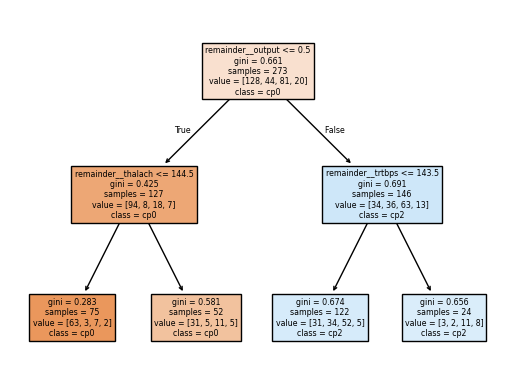

In [302]:
plot_tree(dt_best_pipeline.named_steps["dt"], feature_names = feature_names, class_names = ["cp0", "cp1", "cp2", "cp3"], filled=True)

The first split happens when output <= 0.5 or output > 0.5. In the branch where the former is true, then see if thalach <= 144.5 or thalach > 144.5. If the former is true, then the patient is classified as cp0. If the latter is true, then the patient is also classified as cp0.

In the right branch, look if trtbps <= 143.5 or trtbps > 143.5. Either way, both patients end up classified as cp2.

This shows why the tuning found that max_depth = 1 is most efficient, because the first root node could give the same determinations.

**LDA**

In [303]:
# make pipeline for LDA
lda_pipeline = Pipeline(
  [
  ("dummy", ct_dummies),
  ("standardize", StandardScaler()),
  ("lda", LinearDiscriminantAnalysis())]
)

# fit
lda_fitted = lda_pipeline.fit(X, y)

## Q2:  OvR

Create a new column in the `ha` dataset called `cp_is_3`, which is equal to `1` if the `cp` variable is equal to `3` and `0` otherwise.

Then, fit a Logistic Regression to predict this new target, and report the **F1 Score**.

Repeat for the other three `cp` categories.  Which category was the OvR approach best at distinguishing?

**CP = 3**

In [304]:
# adjust data
ha["cp_is_3"] = (ha["cp"] == 3) * 1
y = ha["cp_is_3"]

In [305]:
# make pipeline for logistic tuning
logistic_pipeline = Pipeline(
  [
   ("dummy", ct_dummies),
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1'))
  ]
).set_output(transform="pandas")

# tune lasso penalty hyperparameter
param_grid = [
    {'logistic__penalty': ['l1', 'none'],
     'logistic__C': np.array([0.001, 0.01, 0.1, 1, 10, 100]),
     'logistic__solver': ['liblinear', 'saga']
    }
]

gscv = GridSearchCV(logistic_pipeline, param_grid=param_grid, cv = 5, scoring='roc_auc')

# feed in the data
gscv_fitted = gscv.fit(X, y)

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_.sort_values(by = "rank_test_score", ascending = True)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logistic__C,param_logistic__penalty,param_logistic__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
20,0.023942,0.018358,0.009705,0.000986,100.000,l1,liblinear,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.367647,0.607843,0.887255,0.945,0.3600,0.633549,0.248017,1
21,0.016467,0.000840,0.008887,0.000471,100.000,l1,saga,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.367647,0.607843,0.887255,0.945,0.3550,0.632549,0.249126,2
16,0.025287,0.022562,0.017328,0.007740,10.000,l1,liblinear,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.367647,0.598039,0.887255,0.945,0.3550,0.630588,0.249351,3
17,0.019111,0.001465,0.010609,0.002055,10.000,l1,saga,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.367647,0.598039,0.887255,0.945,0.3500,0.629588,0.250461,4
13,0.013719,0.001537,0.008685,0.000736,1.000,l1,saga,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.352941,0.598039,0.882353,0.935,0.2950,0.612667,0.262760,5
12,0.009846,0.000174,0.007770,0.000121,1.000,l1,liblinear,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.357843,0.598039,0.882353,0.935,0.2900,0.612647,0.263018,6
0,0.016107,0.003576,0.012607,0.001424,0.001,l1,liblinear,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.500000,0.500,0.5000,0.500000,0.000000,7
1,0.016322,0.001129,0.012870,0.001295,0.001,l1,saga,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.500000,0.500,0.5000,0.500000,0.000000,7
5,0.010091,0.000571,0.007698,0.000105,0.010,l1,saga,"{'logistic__C': 0.01, 'logistic__penalty': 'l1...",0.500000,0.500000,0.500000,0.500,0.5000,0.500000,0.000000,7
4,0.011024,0.002047,0.008814,0.001958,0.010,l1,liblinear,"{'logistic__C': 0.01, 'logistic__penalty': 'l1...",0.500000,0.500000,0.500000,0.500,0.5000,0.500000,0.000000,7


In [306]:
# make pipeline for C = 100, penalty = l1, solver = liblinear
logistic_best_pipeline_cp3 = Pipeline(
  [
   ("dummy", ct_dummies),
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1', C = 100, solver = 'liblinear'))
  ]
).set_output(transform="pandas")

# fit
logistic_best_pipeline_fitted = logistic_best_pipeline_cp3.fit(X, y)

In [307]:
# create empty list of f1 scores
f1_compare = []

# cross-validation to estimate f1_macro
scores = cross_val_score(logistic_best_pipeline_cp3,
                         X=X,
                         y=y,
                         scoring="f1_macro",
                         cv=5)
# add to list
f1_compare.append(scores.mean())
scores.mean()

np.float64(0.4799787225048262)

**CP = 2**

In [308]:
# adjust data
ha["cp_is_2"] = (ha["cp"] == 2) * 1
y = ha["cp_is_2"]

In [309]:
# make pipeline for logistic tuning
logistic_pipeline = Pipeline(
  [
   ("dummy", ct_dummies),
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1'))
  ]
).set_output(transform="pandas")

# tune lasso penalty hyperparameter
param_grid = [
    {'logistic__penalty': ['l1', 'none'],
     'logistic__C': np.array([0.001, 0.01, 0.1, 1, 10, 100]),
     'logistic__solver': ['liblinear', 'saga']
    }
]

gscv = GridSearchCV(logistic_pipeline, param_grid=param_grid, cv = 5, scoring='roc_auc')

# feed in the data
gscv_fitted = gscv.fit(X, y)

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_.sort_values(by = "rank_test_score", ascending = True)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logistic__C,param_logistic__penalty,param_logistic__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
9,0.012123,0.000906,0.009005,0.000922,0.100,l1,saga,"{'logistic__C': 0.1, 'logistic__penalty': 'l1'...",0.400641,0.333333,0.929567,0.937500,0.412829,0.602774,0.271430,1
8,0.010257,0.000159,0.008206,0.000318,0.100,l1,liblinear,"{'logistic__C': 0.1, 'logistic__penalty': 'l1'...",0.400641,0.333333,0.929567,0.937500,0.412829,0.602774,0.271430,1
17,0.016614,0.001463,0.009129,0.000702,10.000,l1,saga,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.386218,0.339744,0.883901,0.873355,0.394737,0.575591,0.248158,3
16,0.010723,0.000513,0.008630,0.001135,10.000,l1,liblinear,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.386218,0.339744,0.883901,0.873355,0.394737,0.575591,0.248158,3
21,0.013984,0.002863,0.009034,0.000706,100.000,l1,saga,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.383013,0.341346,0.882353,0.873355,0.394737,0.574961,0.247964,5
20,0.012877,0.002449,0.008536,0.000623,100.000,l1,liblinear,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.381410,0.341346,0.882353,0.873355,0.393092,0.574311,0.248452,6
13,0.014737,0.002002,0.009426,0.001583,1.000,l1,saga,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.397436,0.333333,0.880805,0.871711,0.375000,0.571657,0.249572,7
12,0.010287,0.000394,0.007785,0.000089,1.000,l1,liblinear,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.394231,0.331731,0.880805,0.871711,0.373355,0.570366,0.250585,8
0,0.012565,0.002748,0.010707,0.002827,0.001,l1,liblinear,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,9
1,0.010075,0.000224,0.007853,0.000104,0.001,l1,saga,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,9


In [310]:
# make pipeline for C = 0.100, penalty = l1, solver = liblinear
logistic_best_pipeline_cp2 = Pipeline(
  [
   ("dummy", ct_dummies),
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1', C = 0.100, solver = 'liblinear'))
  ]
).set_output(transform="pandas")

# fit
logistic_best_pipeline_fitted = logistic_best_pipeline_cp2.fit(X, y)

In [311]:
# cross-validation to estimate f1_macro
scores = cross_val_score(logistic_best_pipeline_cp2,
                         X=X,
                         y=y,
                         scoring="f1_macro",
                         cv=5)
# add to list
f1_compare.append(scores.mean())
scores.mean()

np.float64(0.37786032680246523)

**CP = 1**

In [312]:
# adjust data
ha["cp_is_1"] = (ha["cp"] == 1) * 1
y = ha["cp_is_1"]

In [313]:
# make pipeline for logistic tuning
logistic_pipeline = Pipeline(
  [
   ("dummy", ct_dummies),
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1'))
  ]
).set_output(transform="pandas")

# tune lasso penalty hyperparameter
param_grid = [
    {'logistic__penalty': ['l1', 'none'],
     'logistic__C': np.array([0.001, 0.01, 0.1, 1, 10, 100]),
     'logistic__solver': ['liblinear', 'saga']
    }
]

gscv = GridSearchCV(logistic_pipeline, param_grid=param_grid, cv = 5, scoring='roc_auc')

# feed in the data
gscv_fitted = gscv.fit(X, y)

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_.sort_values(by = "rank_test_score", ascending = True)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logistic__C,param_logistic__penalty,param_logistic__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
9,0.011693,0.001219,0.008148,0.000306,0.100,l1,saga,"{'logistic__C': 0.1, 'logistic__penalty': 'l1'...",0.743961,0.657005,0.752415,0.741848,0.706173,0.720280,0.035388,1
8,0.010231,0.000239,0.008529,0.000798,0.100,l1,liblinear,"{'logistic__C': 0.1, 'logistic__penalty': 'l1'...",0.743961,0.657005,0.752415,0.741848,0.706173,0.720280,0.035388,1
20,0.022659,0.006445,0.009244,0.000779,100.000,l1,liblinear,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.729469,0.599034,0.756039,0.779891,0.649383,0.702763,0.067984,3
21,0.016273,0.000212,0.008796,0.000543,100.000,l1,saga,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.729469,0.599034,0.756039,0.779891,0.646914,0.702269,0.068378,4
13,0.014196,0.002550,0.008461,0.000359,1.000,l1,saga,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.723430,0.613527,0.760870,0.777174,0.634568,0.701914,0.066258,5
17,0.016731,0.000580,0.008818,0.000837,10.000,l1,saga,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.729469,0.596618,0.753623,0.779891,0.649383,0.701797,0.068352,6
12,0.011350,0.001196,0.009574,0.001627,1.000,l1,liblinear,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.723430,0.615942,0.758454,0.774457,0.634568,0.701370,0.064571,7
16,0.012419,0.001781,0.008915,0.000685,10.000,l1,liblinear,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.729469,0.596618,0.753623,0.779891,0.646914,0.701303,0.068737,8
0,0.011299,0.001846,0.008531,0.000695,0.001,l1,liblinear,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,9
1,0.010280,0.000333,0.008088,0.000281,0.001,l1,saga,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,9


In [314]:
# make pipeline for C = 0.100, penalty = l1, solver = liblinear
logistic_best_pipeline_cp1 = Pipeline(
  [
   ("dummy", ct_dummies),
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1', C = 0.100, solver = 'liblinear'))
  ]
).set_output(transform="pandas")

# fit
logistic_best_pipeline_fitted = logistic_best_pipeline_cp1.fit(X, y)

In [315]:
# cross-validation to estimate f1_macro
scores = cross_val_score(logistic_best_pipeline_cp1,
                         X=X,
                         y=y,
                         scoring="f1_macro",
                         cv=5)
# add to list
f1_compare.append(scores.mean())
scores.mean()

np.float64(0.45617641764176414)

**CP = 0**

In [316]:
# adjust data
ha["cp_is_0"] = (ha["cp"] == 0) * 1
y = ha["cp_is_0"]

In [317]:
# make pipeline for logistic tuning
logistic_pipeline = Pipeline(
  [
   ("dummy", ct_dummies),
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1'))
  ]
).set_output(transform="pandas")

# tune lasso penalty hyperparameter
param_grid = [
    {'logistic__penalty': ['l1', 'none'],
     'logistic__C': np.array([0.001, 0.01, 0.1, 1, 10, 100]),
     'logistic__solver': ['liblinear', 'saga']
    }
]

gscv = GridSearchCV(logistic_pipeline, param_grid=param_grid, cv = 5, scoring='roc_auc')

# feed in the data
gscv_fitted = gscv.fit(X, y)

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_.sort_values(by = "rank_test_score", ascending = True)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logistic__C,param_logistic__penalty,param_logistic__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
9,0.011043,0.000533,0.007989,0.000159,0.100,l1,saga,"{'logistic__C': 0.1, 'logistic__penalty': 'l1'...",0.572944,0.935013,0.998674,0.948276,0.668966,0.824775,0.170494,1
8,0.010607,0.000439,0.008381,0.000367,0.100,l1,liblinear,"{'logistic__C': 0.1, 'logistic__penalty': 'l1'...",0.572944,0.935013,0.998674,0.948276,0.668966,0.824775,0.170494,1
12,0.009840,0.000177,0.007798,0.000118,1.000,l1,liblinear,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.588859,0.867374,0.990716,0.920000,0.560000,0.785390,0.176876,3
13,0.012062,0.000961,0.007877,0.000104,1.000,l1,saga,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.587533,0.867374,0.990716,0.921379,0.558621,0.785125,0.177733,4
17,0.014566,0.001485,0.008129,0.000285,10.000,l1,saga,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.592838,0.863395,0.989390,0.915862,0.555862,0.783469,0.175764,5
16,0.010279,0.000757,0.007907,0.000094,10.000,l1,liblinear,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.592838,0.863395,0.989390,0.915862,0.555862,0.783469,0.175764,5
20,0.013179,0.001712,0.008121,0.000179,100.000,l1,liblinear,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.592838,0.862069,0.989390,0.915862,0.554483,0.782928,0.176002,7
21,0.013704,0.002679,0.008365,0.000406,100.000,l1,saga,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.592838,0.862069,0.989390,0.915862,0.554483,0.782928,0.176002,7
0,0.010861,0.000921,0.009435,0.001341,0.001,l1,liblinear,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,9
1,0.010248,0.000302,0.008118,0.000121,0.001,l1,saga,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,9


In [318]:
# make pipeline for C = 0.100, penalty = l1, solver = liblinear
logistic_best_pipeline_cp0 = Pipeline(
  [
   ("dummy", ct_dummies),
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1', C = 0.100, solver = 'liblinear'))
  ]
).set_output(transform="pandas")

# fit
logistic_best_pipeline_fitted = logistic_best_pipeline_cp0.fit(X, y)

In [319]:
# cross-validation to estimate f1_macro
scores = cross_val_score(logistic_best_pipeline_cp0,
                         X=X,
                         y=y,
                         scoring="f1_macro",
                         cv=5)
# add to list
f1_compare.append(scores.mean())
scores.mean()

np.float64(0.6761418023146053)

In [320]:
# create dataframe for comparing f1 values
f1_compare_df = pd.DataFrame({
    "model with specific target class": ["cp3", "cp2", "cp1", "cp0"],
    "f1_values": f1_compare
})

f1_compare_df.sort_values(by = "f1_values", ascending = False)

,model with specific target class,f1_values
3,cp0,0.676142
0,cp3,0.479979
2,cp1,0.456176
1,cp2,0.377860


The OvR approach is best at distinguishing the target class of cp = 0. This is seen by how treating cp = 0 as the target class yields the best f1 score.

## Q3: OvO

Reduce your dataset to only the `0` and `1` types of chest pain.

Then, fit a Logistic Regression to predict between the two groups, and report the **ROC-AUC**.  

Repeat comparing category `0` to `2` and `3`.  Which pair was the OvO approach best at distinguishing?

**CP = 1 vs CP = 0**

In [321]:
# adjust data
ha_01 = ha[(ha["cp"] == 0) | (ha["cp"] == 1)]
ha_01 = ha_01.drop(columns = ["cp_is_3", "cp_is_2", "cp_is_1", "cp_is_0"])

X = ha_01.drop(columns = ["cp"])
y = ha_01["cp"].astype(str)

In [322]:
print(X.columns)


Index(['age', 'sex', 'trtbps', 'chol', 'restecg', 'thalach', 'output'], dtype='object')


In [323]:
# make pipeline for logistic tuning
logistic_pipeline = Pipeline(
  [
   ("dummy", ct_dummies),
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1'))
  ]
).set_output(transform="pandas")

# tune lasso penalty hyperparameter
param_grid = [
    {'logistic__penalty': ['l1', 'none'],
     'logistic__C': np.array([0.001, 0.01, 0.1, 1, 10, 100]),
     'logistic__solver': ['liblinear', 'saga']
    }
]

gscv = GridSearchCV(logistic_pipeline, param_grid=param_grid, cv = 5, scoring='roc_auc')

# feed in the data
gscv_fitted = gscv.fit(X, y)

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_.sort_values(by = "rank_test_score", ascending = True)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logistic__C,param_logistic__penalty,param_logistic__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
8,0.009916,0.000241,0.007891,0.000133,0.100,l1,liblinear,"{'logistic__C': 0.1, 'logistic__penalty': 'l1'...",0.794872,0.948718,0.986667,0.995556,0.697115,0.884585,0.118357,1
9,0.011483,0.001749,0.008702,0.001801,0.100,l1,saga,"{'logistic__C': 0.1, 'logistic__penalty': 'l1'...",0.794872,0.948718,0.982222,0.995556,0.697115,0.883697,0.117601,2
13,0.014468,0.005539,0.012589,0.004910,1.000,l1,saga,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.782051,0.935897,0.960000,0.955556,0.668269,0.860355,0.116385,3
12,0.010828,0.001107,0.008406,0.000516,1.000,l1,liblinear,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.782051,0.935897,0.960000,0.955556,0.663462,0.859393,0.117977,4
17,0.021973,0.004171,0.014173,0.002881,10.000,l1,saga,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.743590,0.918803,0.951111,0.937778,0.653846,0.841026,0.120049,5
20,0.018835,0.004277,0.011683,0.000928,100.000,l1,liblinear,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.743590,0.914530,0.951111,0.937778,0.653846,0.840171,0.119506,6
16,0.010933,0.001144,0.008217,0.000378,10.000,l1,liblinear,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.743590,0.918803,0.951111,0.937778,0.649038,0.840064,0.121554,7
21,0.021679,0.001036,0.011591,0.000508,100.000,l1,saga,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.743590,0.914530,0.951111,0.937778,0.649038,0.839209,0.121012,8
0,0.011656,0.002202,0.008624,0.000666,0.001,l1,liblinear,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,9
1,0.010714,0.000695,0.008089,0.000313,0.001,l1,saga,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,9


In [324]:
# make pipeline for C = 0.100, penalty = l1, solver = liblinear
logistic_best_pipeline_1v0 = Pipeline(
  [
   ("dummy", ct_dummies),
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1', C = 0.100, solver = 'liblinear'))
  ]
).set_output(transform="pandas")

# fit
logistic_best_pipeline_fitted = logistic_best_pipeline_1v0.fit(X, y)

In [325]:
# create empty list of f1 roc_auc
roc_compare = []

# cross-validation to estimate roc_auc
scores = cross_val_score(logistic_best_pipeline_1v0,
                         X=X,
                         y=y,
                         scoring="roc_auc",
                         cv=5)
# add to list
roc_compare.append(scores.mean())
scores.mean()

np.float64(0.8845854700854702)

**CP = 0 vs CP = 2**

In [326]:
# adjust data
ha_02 = ha[(ha["cp"] == 0) | (ha["cp"] == 2)]
ha_02 = ha_02.drop(columns = ["cp_is_3", "cp_is_2", "cp_is_1", "cp_is_0"])

X = ha_02.drop(columns = ["cp"])
y = ha_02["cp"].astype(str)

In [327]:
# make pipeline for logistic tuning
logistic_pipeline = Pipeline(
  [
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1'))
  ]
).set_output(transform="pandas")

# tune lasso penalty hyperparameter
param_grid = [
    {'logistic__penalty': ['l1', 'none'],
     'logistic__C': np.array([0.001, 0.01, 0.1, 1, 10, 100]),
     'logistic__solver': ['liblinear', 'saga']
    }
]

gscv = GridSearchCV(logistic_pipeline, param_grid=param_grid, cv = 5, scoring='roc_auc')

# feed in the data
gscv_fitted = gscv.fit(X, y)

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_.sort_values(by = "rank_test_score", ascending = True)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logistic__C,param_logistic__penalty,param_logistic__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
9,0.008128,0.000280,0.006065,0.000239,0.100,l1,saga,"{'logistic__C': 0.1, 'logistic__penalty': 'l1'...",0.544706,0.918269,1.000000,0.965144,0.64625,0.814874,0.183830,1
8,0.008850,0.001936,0.006848,0.000752,0.100,l1,liblinear,"{'logistic__C': 0.1, 'logistic__penalty': 'l1'...",0.544706,0.918269,1.000000,0.965144,0.64625,0.814874,0.183830,1
12,0.007726,0.000219,0.006629,0.000753,1.000,l1,liblinear,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.545882,0.788462,0.985577,0.949519,0.55500,0.764888,0.187278,3
13,0.009687,0.000998,0.006570,0.000269,1.000,l1,saga,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.545882,0.788462,0.985577,0.949519,0.55250,0.764388,0.187840,4
17,0.008635,0.000822,0.006151,0.000412,10.000,l1,saga,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.541176,0.788462,0.983173,0.951923,0.53000,0.758947,0.194025,5
16,0.007500,0.000595,0.006659,0.001261,10.000,l1,liblinear,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.541176,0.788462,0.983173,0.951923,0.53000,0.758947,0.194025,5
20,0.008330,0.000938,0.006525,0.000906,100.000,l1,liblinear,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.536471,0.788462,0.983173,0.949519,0.52500,0.756525,0.195788,7
21,0.008809,0.000603,0.006781,0.001003,100.000,l1,saga,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.536471,0.788462,0.983173,0.949519,0.52500,0.756525,0.195788,7
0,0.009517,0.003918,0.006701,0.001161,0.001,l1,liblinear,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.500000,0.500000,0.50000,0.500000,0.000000,9
1,0.007418,0.000399,0.006388,0.000920,0.001,l1,saga,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.500000,0.500000,0.50000,0.500000,0.000000,9


In [328]:
# make pipeline for C = 0.100, penalty = l1, solver = liblinear
logistic_best_pipeline_0v2 = Pipeline(
  [
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1', C = 0.100, solver = 'liblinear'))
  ]
).set_output(transform="pandas")

# fit
logistic_best_pipeline_fitted = logistic_best_pipeline_0v2.fit(X, y)

In [329]:
# cross-validation to estimate roc_auc
scores = cross_val_score(logistic_best_pipeline_0v2,
                         X=X,
                         y=y,
                         scoring="roc_auc",
                         cv=5)
# add to list
roc_compare.append(scores.mean())
scores.mean()

np.float64(0.8148738687782805)

**CP = 0 vs CP = 3**

In [330]:
# adjust data
ha_03 = ha[(ha["cp"] == 0) | (ha["cp"] == 3)]
ha_03 = ha_03.drop(columns = ["cp_is_3", "cp_is_2", "cp_is_1", "cp_is_0"])

X = ha_03.drop(columns = ["cp"])
y = ha_03["cp"].astype(str)

In [331]:
# make pipeline for logistic tuning
logistic_pipeline = Pipeline(
  [
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1'))
  ]
).set_output(transform="pandas")

# tune lasso penalty hyperparameter
param_grid = [
    {'logistic__penalty': ['l1', 'none'],
     'logistic__C': np.array([0.001, 0.01, 0.1, 1, 10, 100]),
     'logistic__solver': ['liblinear', 'saga']
    }
]

gscv = GridSearchCV(logistic_pipeline, param_grid=param_grid, cv = 5, scoring='roc_auc')

# feed in the data
gscv_fitted = gscv.fit(X, y)

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_.sort_values(by = "rank_test_score", ascending = True)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logistic__C,param_logistic__penalty,param_logistic__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
12,0.004936,0.000034,0.004139,0.000054,1.000,l1,liblinear,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.423077,0.923077,1.0,0.880,0.48,0.741231,0.240312,1
13,0.005804,0.000409,0.004251,0.000161,1.000,l1,saga,"{'logistic__C': 1.0, 'logistic__penalty': 'l1'...",0.423077,0.923077,1.0,0.880,0.48,0.741231,0.240312,1
17,0.005816,0.000288,0.004220,0.000129,10.000,l1,saga,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.394231,0.932692,1.0,0.890,0.46,0.735385,0.254982,3
16,0.004945,0.000116,0.004127,0.000058,10.000,l1,liblinear,"{'logistic__C': 10.0, 'logistic__penalty': 'l1...",0.394231,0.932692,1.0,0.890,0.46,0.735385,0.254982,3
20,0.005184,0.000216,0.004269,0.000100,100.000,l1,liblinear,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.394231,0.932692,1.0,0.880,0.46,0.733385,0.253798,5
21,0.006102,0.000462,0.004302,0.000092,100.000,l1,saga,"{'logistic__C': 100.0, 'logistic__penalty': 'l...",0.394231,0.932692,1.0,0.880,0.46,0.733385,0.253798,5
0,0.007086,0.003668,0.004382,0.000529,0.001,l1,liblinear,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.5,0.500,0.50,0.500000,0.000000,7
1,0.005529,0.000937,0.004433,0.000348,0.001,l1,saga,"{'logistic__C': 0.001, 'logistic__penalty': 'l...",0.500000,0.500000,0.5,0.500,0.50,0.500000,0.000000,7
5,0.006024,0.001024,0.004599,0.000470,0.010,l1,saga,"{'logistic__C': 0.01, 'logistic__penalty': 'l1...",0.500000,0.500000,0.5,0.500,0.50,0.500000,0.000000,7
4,0.004839,0.000057,0.004174,0.000029,0.010,l1,liblinear,"{'logistic__C': 0.01, 'logistic__penalty': 'l1...",0.500000,0.500000,0.5,0.500,0.50,0.500000,0.000000,7


In [332]:
# make pipeline for C = 1, penalty = l1, solver = liblinear
logistic_best_pipeline_0v3 = Pipeline(
  [
   ("standardize", StandardScaler()),
   ("logistic", LogisticRegression(penalty = 'l1', C = 1, solver = 'liblinear'))
  ]
).set_output(transform="pandas")

# fit
logistic_best_pipeline_fitted = logistic_best_pipeline_0v3.fit(X, y)

In [333]:
# cross-validation to estimate roc_auc
scores = cross_val_score(logistic_best_pipeline_0v3,
                         X=X,
                         y=y,
                         scoring="roc_auc",
                         cv=5)
# add to list
roc_compare.append(scores.mean())
scores.mean()

np.float64(0.7412307692307692)

In [334]:
# create dataframe for comparing roc_auc values
roc_compare_df = pd.DataFrame({
    "comparison": ["cp0 vs cp1", "cp0 vs cp2", "cp0 vs cp3"],
    "roc_auc_values": roc_compare
})

roc_compare_df.sort_values(by = "roc_auc_values", ascending = False)

,comparison,roc_auc_values
0,cp0 vs cp1,0.884585
1,cp0 vs cp2,0.814874
2,cp0 vs cp3,0.741231


The OvO approach is best at distinguishing the cp = 0 and cp = 1 pair. This is seen by how the model built using this limited data produced the best roc_auc score.